In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
admissions = pd.read_csv("admissions.csv")
billing = pd.read_csv("billing.csv")
surgeries = pd.read_csv("raw_surgeries.csv")

Matplotlib is building the font cache; this may take a moment.


In [2]:
admissions.head()

,Admission_ID,Patient_ID,Doctor_ID,Department_ID,Admission_Date,Discharge_Date,Status
0,A00001,P00001,DR00186,D002,2025-10-20,2025-10-28,Critical
1,A00002,P00002,DR00281,D019,2025-01-21,2025-01-23,Recovered
2,A00003,P00003,DR00105,D020,2025-06-24,2025-07-03,Discharged
3,A00004,P00004,DR00312,D004,2025-07-23,2025-07-25,Critical
4,A00005,P00005,DR00430,D018,2025-04-06,2025-04-07,Under Treatment


In [3]:
billing.head()

,Bill_ID,Admission_ID,Patient_ID,Total,Insurance,Paid,Pending
0,B00001,A00001,P00001,70078,93,70001,77
1,B00002,A00002,P00002,20824,4403,17971,2853
2,B00003,A00003,P00003,6432,239,6228,204
3,B00004,A00004,P00004,82670,9986,77817,4853
4,B00005,A00005,P00005,10376,4009,7571,2805


In [4]:
surgeries.head()

,Surgery_ID,Admission_ID,Patient_ID,Doctor_ID,Outcome,Surgery_Type,Surgery_Date,Duration_Minutes,Cost,Surgeon_Name,...,Surgery_Year,Surgery_Month,Surgery_Quarter,Weekday,Is_Weekend,Success_Flag,Duration_Category,Cost_Category,Cost_Per_Minute,Recovery_To_LOS_Ratio
0,S00001,A00001,P00001,DR00186,Success,Tumor Removal,2026-01-20,100,144730,Dr. Manish Arora,...,2026,January,1,Tuesday,False,1,Medium (90-180m),Medium,1447.30,4.46
1,S00002,A00002,P00002,DR00281,Complication,Bypass,2026-02-04,75,269331,Dr. Priya Nair,...,2026,February,1,Wednesday,False,0,Short (<90m),High,3591.08,2.22
2,S00003,A00003,P00003,DR00105,Complication,Gallbladder,2025-09-22,347,449913,Dr. Rohan Mehta,...,2025,September,3,Monday,False,0,Extended (270m+),Very High,1296.58,3.27
3,S00004,A00004,P00004,DR00312,Complication,Angioplasty,2025-05-26,280,382955,Dr. Aarav Sharma,...,2025,May,2,Monday,False,0,Extended (270m+),Very High,1367.70,2.25
4,S00005,A00005,P00005,DR00430,Complication,Hip Replacement,2026-03-13,302,376853,Dr. Meera Thomas,...,2026,March,1,Friday,False,0,Extended (270m+),Very High,1247.86,2.14


In [5]:
print(admissions.columns)
print(billing.columns)
print(surgeries.columns)

Index(['Admission_ID', 'Patient_ID', 'Doctor_ID', 'Department_ID',
       'Admission_Date', 'Discharge_Date', 'Status'],
      dtype='str')
Index(['Bill_ID', 'Admission_ID', 'Patient_ID', 'Total', 'Insurance', 'Paid',
       'Pending'],
      dtype='str')
Index(['Surgery_ID', 'Admission_ID', 'Patient_ID', 'Doctor_ID', 'Outcome',
       'Surgery_Type', 'Surgery_Date', 'Duration_Minutes', 'Cost',
       'Surgeon_Name', 'Assistant_Surgeon_Name', 'Nurse_In_Charge',
       'Operation_Theatre_ID', 'Length_Of_Stay_After_Surgery', 'Recovery_Days',
       'Surgery_Year', 'Surgery_Month', 'Surgery_Quarter', 'Weekday',
       'Is_Weekend', 'Success_Flag', 'Duration_Category', 'Cost_Category',
       'Cost_Per_Minute', 'Recovery_To_LOS_Ratio'],
      dtype='str')


In [6]:
# Merge billing with admissions using Admission_ID
billing_data = pd.merge(
    billing,
    admissions[['Admission_ID', 'Admission_Date']],
    on='Admission_ID',
    how='inner'
)

In [7]:
billing_data.head()

,Bill_ID,Admission_ID,Patient_ID,Total,Insurance,Paid,Pending,Admission_Date
0,B00001,A00001,P00001,70078,93,70001,77,2025-10-20
1,B00002,A00002,P00002,20824,4403,17971,2853,2025-01-21
2,B00003,A00003,P00003,6432,239,6228,204,2025-06-24
3,B00004,A00004,P00004,82670,9986,77817,4853,2025-07-23
4,B00005,A00005,P00005,10376,4009,7571,2805,2025-04-06


In [8]:
billing_data.columns

Index(['Bill_ID', 'Admission_ID', 'Patient_ID', 'Total', 'Insurance', 'Paid',
       'Pending', 'Admission_Date'],
      dtype='str')

In [9]:
billing_data["Admission_Date"] = pd.to_datetime(billing_data["Admission_Date"])

In [10]:
billing_data["Month"] = billing_data["Admission_Date"].dt.to_period("M")

In [11]:
monthly_revenue = billing_data.groupby("Month")["Total"].sum()

monthly_revenue

Month
2025-01    27121384
2025-02    25578901
2025-03    27191823
2025-04    26204792
2025-05    27754669
2025-06    25218162
2025-07    26930461
2025-08    27582780
2025-09    26389104
2025-10    23421029
Freq: M, Name: Total, dtype: int64

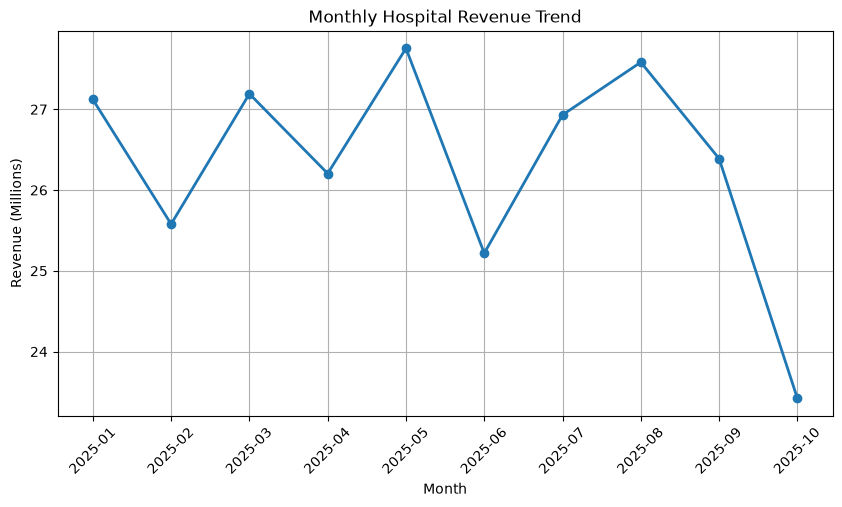

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values / 1_000_000,
    marker='o',
    linewidth=2
)

plt.title("Monthly Hospital Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (Millions)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [14]:
# Convert Admission_Date to datetime
admissions["Admission_Date"] = pd.to_datetime(admissions["Admission_Date"])

In [15]:
# Extract Month-Year
admissions["Month"] = admissions["Admission_Date"].dt.to_period("M")

In [16]:
# Count admissions per month
monthly_admissions = admissions.groupby("Month").size()

monthly_admissions

Month
2025-01    516
2025-02    479
2025-03    504
2025-04    508
2025-05    519
2025-06    505
2025-07    524
2025-08    506
2025-09    500
2025-10    439
Freq: M, dtype: int64

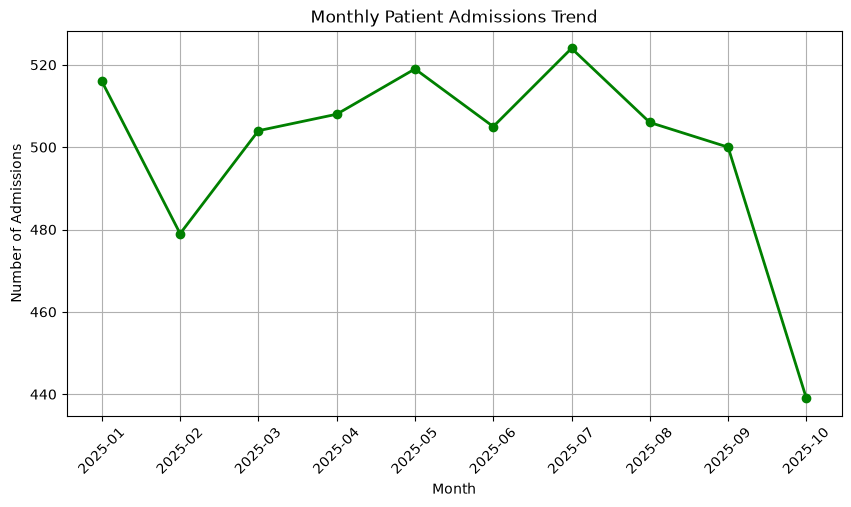

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_admissions.index.astype(str),
    monthly_admissions.values,
    marker='o',
    linewidth=2,
    color='green'
)

plt.title("Monthly Patient Admissions Trend")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [18]:
# Convert Surgery_Date to datetime
surgeries["Surgery_Date"] = pd.to_datetime(surgeries["Surgery_Date"])

In [19]:
# Extract Month-Year
surgeries["Month"] = surgeries["Surgery_Date"].dt.to_period("M")

In [20]:
# Count surgeries per month
monthly_surgeries = surgeries.groupby("Month").size()

monthly_surgeries

Month
2025-01    185
2025-02    182
2025-03    219
2025-04    188
2025-05    203
2025-06    203
2025-07    218
2025-08    184
2025-09    167
2025-10    206
2025-11    212
2025-12    210
2026-01    205
2026-02    185
2026-03    191
2026-04    177
2026-05    202
2026-06    168
Freq: M, dtype: int64

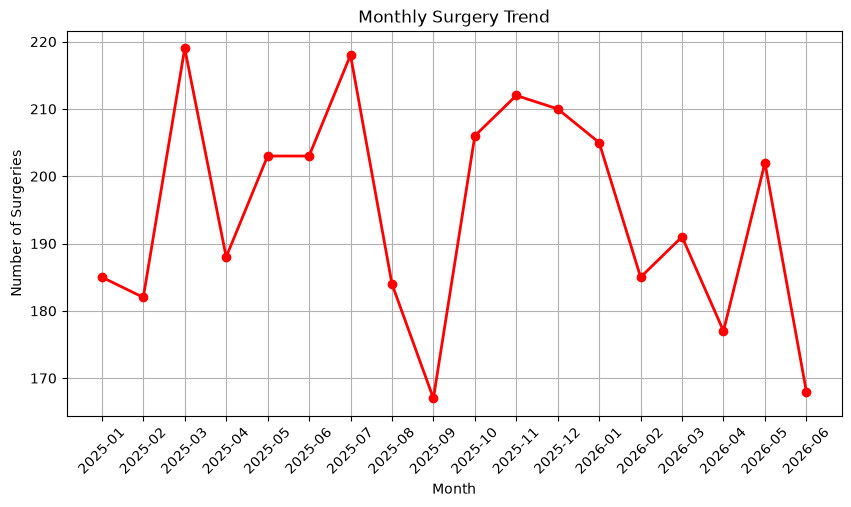

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_surgeries.index.astype(str),
    monthly_surgeries.values,
    marker='o',
    linewidth=2,
    color='red'
)

plt.title("Monthly Surgery Trend")
plt.xlabel("Month")
plt.ylabel("Number of Surgeries")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Trend Analysis on Hospital Dataset

## Objective

The main objective of this project is to study the trends in hospital data over a period of time.
Using the available hospital datasets, I analyzed patient admissions, hospital revenue, and surgeries
to understand how these values change from month to month and to identify any noticeable patterns.

## Analysis Performed

### 1. Monthly Hospital Revenue Trend

To analyze the revenue trend, I combined the billing and admissions datasets using the common `Admission_ID`.
Since the billing dataset did not contain a date column, 
I used the admission date from the admissions dataset to calculate the monthly revenue. 
The analysis showed that the hospital's revenue remained fairly stable throughout the year, with the highest revenue recorded in **May 2025** and the lowest in **October 2025**.

### 2. Monthly Patient Admissions Trend

For the admissions analysis, I used the `Admission_Date` column to calculate the total number of patient admissions 
each month. The results showed that the number of admissions remained consistent for most of the year, with a slight
 increase in **July 2025** and a noticeable decrease in **October 2025**.

### 3. Monthly Surgery Trend

The surgery trend was analyzed using the `Surgery_Date` column from the surgeries dataset. The monthly analysis showed that the number of surgeries varied 
slightly from month to month. The highest number of surgeries was performed in **March 2025**, while the lowest was observed in **September 2025**. Overall, 
the surgery trend remained stable without any major fluctuations.

## Conclusion

From this trend analysis, it can be observed that the hospital maintained consistent performance over the analyzed period. 
Although there were small monthly increases and decreases in admissions, revenue, and surgeries, there were no major irregularities.
This type of analysis helps hospital management understand operational performance, identify seasonal trends, and make better decisions for planning and resource allocation.